In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [3]:
def plot_loss_curves(history):
    plt.clf()
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)
    plt.plot(epochs, loss_values, "bo", label="Training loss")
    plt.plot(epochs, val_loss_values, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def plot_acc_curves(history):
    plt.clf()
    history_dict = history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training acc")
    plt.plot(epochs, val_acc, "b", label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

In [4]:
# Read data from URL

train_url = "https://www.dropbox.com/scl/fi/ito6bnl2yaf1uw0uqibzf/lyric_genre_train.csv?rlkey=04dkn5un2djza8x0bdmfnlw3u&st=y47qh8i4&dl=1"
val_url = "https://www.dropbox.com/scl/fi/xmywjzqsaa8n5sn1bs0t9/lyric_genre_val.csv?rlkey=hggbeo0s1iaxjpa6z80429xl9&st=6i7d8eau&dl=1"
test_url = "https://www.dropbox.com/scl/fi/fnocl69w9ojs9s5zb0xvf/lyric_genre_test.csv?rlkey=z4hjopw7vaihoh948cbb5mvdp&st=xwond7dp&dl=1"

train_df = pd.read_csv(train_url,index_col=0)
val_df = pd.read_csv(val_url,index_col=0)
test_df = pd.read_csv(test_url,index_col=0)


print(f"""
Train samples: {train_df.shape[0]}
Validation samples: {val_df.shape[0]}
Test samples: {test_df.shape[0]}
""")


Train samples: 48991
Validation samples: 16331
Test samples: 21774



In [5]:
# Let's one-hot-encode the target
y_train = pd.get_dummies(train_df['Genre']).to_numpy()
y_val = pd.get_dummies(val_df['Genre']).to_numpy()
y_test = pd.get_dummies(test_df['Genre']).to_numpy()

In [9]:
# Delete the corrupted file first
!rm -f glove.6B.zip

# Download using the -L flag to follow redirects and https
!curl -LO https://nlp.stanford.edu/data/glove.6B.zip

# Unzip the clean download
!unzip -q glove.6B.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0   346    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  822M  100  822M    0     0  5294k      0  0:02:39  0:02:39 --:--:-- 5107k0M      0  0:00:43  0:00:01  0:00:42 21.0M4 5183k:02:35  0:01:27  0:01:08 5156k0:01:37  0:00:59 5176k69k      0  0:02:36  0:01:44  0:00:52 5113k53k      0  0:02:37  0:01:52  0:00:45 5158k     0  0:02:37  0:01:58  0:00:39 5155k   0  0:02:38  0:02:21  0:00:17 5168k00k      0  0:02:38  0:02:34  0:00:04 5120k


In [11]:
!head -n 1 glove.6B.100d.txt

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062


In [14]:
embedding_dim = 100
path_to_glove_file = f"glove.6B.{embedding_dim}d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

Found 400000 word vectors.


In [15]:
embeddings_index["movie"]

array([ 0.38251  ,  0.14821  ,  0.60601  , -0.51533  ,  0.43992  ,
        0.061053 , -0.62716  , -0.025385 ,  0.1643   , -0.22101  ,
        0.14423  , -0.37213  , -0.21683  , -0.08895  ,  0.097904 ,
        0.6561   ,  0.64455  ,  0.47698  ,  0.83849  ,  1.6486   ,
        0.88922  , -0.1181   , -0.012465 , -0.52082  ,  0.77854  ,
        0.48723  , -0.014991 , -0.14127  , -0.34747  , -0.29595  ,
        0.1028   ,  0.57191  , -0.045594 ,  0.026443 ,  0.53816  ,
        0.32257  ,  0.40788  , -0.043599 , -0.146    , -0.48346  ,
        0.32036  ,  0.55086  , -0.76259  ,  0.43269  ,  0.61753  ,
       -0.36503  , -0.60599  , -0.79615  ,  0.3929   , -0.23668  ,
       -0.34719  , -0.61201  ,  0.54747  ,  0.94812  ,  0.20941  ,
       -2.7771   , -0.6022   ,  0.8495   ,  1.2549   ,  0.017893 ,
       -0.041901 ,  2.1147   , -0.026618 , -0.28104  ,  0.68124  ,
       -0.14165  ,  0.99249  ,  0.49879  , -0.67538  ,  0.6417   ,
        0.42303  , -0.27913  ,  0.063403 ,  0.68909  , -0.3618

In [16]:
embeddings_index["film"]

array([ 0.19916 , -0.049702,  0.24579 , -0.32281 ,  0.89768 , -0.1278  ,
       -0.49506 ,  0.20814 , -0.20046 , -0.20604 ,  0.038292, -0.67277 ,
       -0.12689 , -0.18766 , -0.10277 ,  0.73128 ,  0.82408 ,  0.087288,
        0.69255 ,  1.3107  ,  0.49113 , -0.38097 ,  0.24338 , -0.27813 ,
        0.62506 ,  0.35978 ,  0.42041 , -0.24529 ,  0.14861 , -0.26726 ,
       -0.56262 ,  0.63843 , -0.54153 ,  0.36537 ,  0.20545 , -0.16604 ,
        0.72434 ,  0.29961 , -0.42501 , -0.35932 , -0.089288,  0.48752 ,
       -1.0927  ,  0.88818 ,  0.89941 , -0.7541  , -0.35492 , -0.76396 ,
        0.27468 ,  0.2757  , -0.48152 , -0.41399 ,  0.64489 ,  1.148   ,
       -0.29131 , -2.9387  , -0.83162 ,  0.95586 ,  1.1623  , -0.42502 ,
        0.15486 ,  2.2326  , -0.31339 , -0.030228,  0.79802 , -0.41302 ,
        0.72885 ,  0.7296  , -0.31909 ,  0.8956  ,  0.34625 ,  0.2923  ,
        0.40056 ,  0.78985 , -0.43999 ,  0.24698 , -0.46548 ,  0.055886,
       -0.62603 , -0.036487, -0.65429 ,  0.10563 , 

In [17]:
max_length = 300 #90% of songs
max_tokens = 5000

text_vectorization = keras.layers.TextVectorization(max_tokens=max_tokens, output_mode="int", output_sequence_length=max_length,)

In [18]:
text_vectorization.adapt(train_df['Lyric'])

In [19]:
text_vectorization.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('you'),
 np.str_('i'),
 np.str_('to'),
 np.str_('and'),
 np.str_('a'),
 np.str_('me'),
 np.str_('it')]

In [20]:
text_vectorization(["HODL, you are the best!"])

<tf.Tensor: shape=(1, 300), dtype=int64, numpy=
array([[  1,   3,  58,   2, 258,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
   

In [21]:
X_train = text_vectorization(train_df['Lyric'])
X_val = text_vectorization(val_df['Lyric'])
X_test = text_vectorization(test_df['Lyric'])

In [22]:
vocabulary = text_vectorization.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

counter = 0
embedding_matrix = np.zeros((max_tokens, embedding_dim))
for word, i in word_index.items():
    if i < max_tokens:
        embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
    else:
        counter += 1

In [23]:
embedding_matrix.shape

(5000, 100)

In [24]:
embedding_matrix[:3,:]

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [ ]:
embedding_layer = keras.layers.Embedding(max_tokens, embedding_dim, embeddings_initializer=keras.initializers.Constant(embedding_matrix), trainable=False, mask_zero=True)

In [26]:
inputs = keras.Input(shape=(max_length, ))
embedded = embedding_layer(inputs) # 300 x 100 table comes out
embedded = keras.layers.GlobalAveragePooling1D()(embedded) # 100-element vector
x = keras.layers.Dense(8, activation='relu')(embedded) # only hidden layer
outputs = keras.layers.Dense(3, activation="softmax")(x) # output layer

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │    500,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 300)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │         27 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 835 (3.26 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [27]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.        0.        0.       ...  0.        0.        0.      ]
  [ 0.        0.        0.       ...  0.        0.        0.      ]
  [-0.038194 -0.24487   0.72812  ... -0.1459    0.8278    0.27062 ]
  ...
  [ 0.33947   0.16186   0.083984 ... -0.66934  -0.073064  0.91467 ]
  [-0.09169   0.10361   0.23232  ... -0.13697  -0.81738   0.3868  ]
  [ 0.28468  -0.26489   0.1649   ... -0.6158   -0.10085   1.0357  ]]>]

In [28]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
# Fit model

history = model.fit(x=X_train, y=y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32,)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5487 - loss: 0.9270 - val_accuracy: 0.5556 - val_loss: 0.8888
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5824 - loss: 0.8617 - val_accuracy: 0.5870 - val_loss: 0.8445
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6043 - loss: 0.8304 - val_accuracy: 0.6047 - val_loss: 0.8219
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6194 - loss: 0.8093 - val_accuracy: 0.6220 - val_loss: 0.8001
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6284 - loss: 0.7950 - val_accuracy: 0.6303 - val_loss: 0.7899
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6329 - loss: 0.7871 - val_accuracy: 0.6334 - val_loss: 0.7829
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6360 - loss: 0.7823 - val_accuracy: 0.6371 - val_loss: 0.7798
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6388 - loss: 0.7780 - 

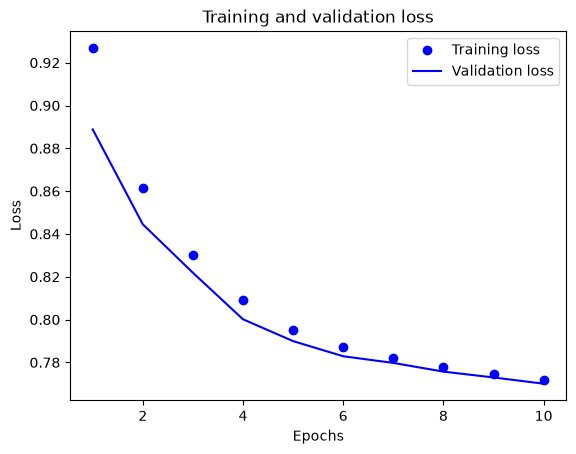

In [30]:
plot_loss_curves(history)

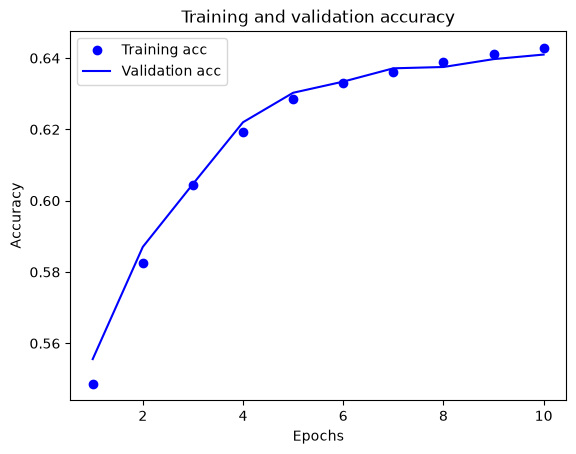

In [31]:
plot_acc_curves(history)

In [32]:
model.evaluate(x=X_test, y=y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6356 - loss: 0.7870


[0.7870206832885742, 0.6355745196342468]

In [33]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.        0.        0.       ...  0.        0.        0.      ]
  [ 0.        0.        0.       ...  0.        0.        0.      ]
  [-0.038194 -0.24487   0.72812  ... -0.1459    0.8278    0.27062 ]
  ...
  [ 0.33947   0.16186   0.083984 ... -0.66934  -0.073064  0.91467 ]
  [-0.09169   0.10361   0.23232  ... -0.13697  -0.81738   0.3868  ]
  [ 0.28468  -0.26489   0.1649   ... -0.6158   -0.10085   1.0357  ]]>]

In [36]:
embedding_layer = keras.layers.Embedding(max_tokens, embedding_dim, embeddings_initializer=keras.initializers.Constant(embedding_matrix), trainable=True, mask_zero=True)

inputs = keras.Input(shape=(max_length,))
embedded = embedding_layer(inputs)
embedded = keras.layers.GlobalAveragePooling1D()(embedded)
x = keras.layers.Dense(8, activation='relu')(embedded)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(3, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 300, 100)  │    500,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 300)       │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding_2[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8)         │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │         27 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 500,835 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding_2/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.        0.        0.       ...  0.        0.        0.      ]
  [ 0.        0.        0.       ...  0.        0.        0.      ]
  [-0.038194 -0.24487   0.72812  ... -0.1459    0.8278    0.27062 ]
  ...
  [ 0.33947   0.16186   0.083984 ... -0.66934  -0.073064  0.91467 ]
  [-0.09169   0.10361   0.23232  ... -0.13697  -0.81738   0.3868  ]
  [ 0.28468  -0.26489   0.1649   ... -0.6158   -0.10085   1.0357  ]]>]

In [38]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [39]:
# Fit model
history = model.fit(x=X_train, y=y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32,)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5562 - loss: 0.8819 - val_accuracy: 0.6439 - val_loss: 0.7737
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6211 - loss: 0.8086 - val_accuracy: 0.6595 - val_loss: 0.7415
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6307 - loss: 0.7703 - val_accuracy: 0.6730 - val_loss: 0.6952
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6399 - loss: 0.7445 - val_accuracy: 0.6750 - val_loss: 0.6945
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6401 - loss: 0.7337 - val_accuracy: 0.6899 - val_loss: 0.6781
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6502 - loss: 0.7105 - val_accuracy: 0.6941 - val_loss: 0.6753
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6565 - loss: 0.6991 - val_accuracy: 0.6925 - val_loss: 0.6692
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6602 - loss: 0.6933 - 

In [40]:
model.evaluate(x=X_test, y=y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6971 - loss: 0.6803


[0.6803484559059143, 0.6970698833465576]

In [41]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding_2/embeddings, shape=(5000, 100), dtype=float32, value=[[ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.04232258 -0.0360189  -0.3498838  ...  0.352316   -0.10765773
   -0.5236391 ]
  [-0.08361501 -0.19783369  0.5022498  ...  0.09400129  0.8041801
   -0.14977859]
  ...
  [ 0.05602183  0.4403518   0.32287604 ... -0.9206055   0.1625986
    0.5548019 ]
  [ 0.30002922 -0.6235072  -0.4082827  ...  0.5790644  -1.4992019
    0.8967417 ]
  [ 0.61737245 -0.4854748  -0.1085654  ... -0.3346365  -0.33690807
    1.0436372 ]]>]

In [43]:
inputs = keras.Input(shape=(max_length, ))

embedded = keras.layers.Embedding(input_dim=max_tokens, output_dim=64, mask_zero=True)(inputs)
embedded = keras.layers.GlobalAveragePooling1D()(embedded)
x = keras.layers.Dense(16, activation='relu')(embedded)
x = keras.layers.Dropout(0.5)(x)

outputs = keras.layers.Dense(3, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 300, 64)   │    320,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 300)       │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ embedding_3[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │      1,040 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 3)         │         51 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,091 (1.22 MB)

 Trainable params: 321,091 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding_3/embeddings, shape=(5000, 64), dtype=float32, value=[[ 0.00822203 -0.01623904  0.02718992 ... -0.01419135 -0.0232712
   -0.03445933]
  [-0.03070483 -0.00807657  0.00345129 ... -0.04035274  0.01570851
   -0.01046403]
  [-0.00322319 -0.03660885 -0.03013239 ...  0.02504062 -0.04973106
    0.01718641]
  ...
  [ 0.0263578   0.03838888 -0.02996435 ... -0.01260672 -0.02379847
    0.01418156]
  [ 0.04270215  0.01441319 -0.039488   ... -0.03771802 -0.02434479
   -0.0395027 ]
  [-0.04080839  0.03682581  0.01915051 ...  0.04836718 -0.01598345
    0.0031196 ]]>]

In [45]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [46]:
history = model.fit(x=X_train, y=y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32,)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6451 - loss: 0.7742 - val_accuracy: 0.7010 - val_loss: 0.6556
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7050 - loss: 0.6669 - val_accuracy: 0.7091 - val_loss: 0.6371
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7188 - loss: 0.6365 - val_accuracy: 0.7112 - val_loss: 0.6355
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7243 - loss: 0.6184 - val_accuracy: 0.7126 - val_loss: 0.6370
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7323 - loss: 0.5991 - val_accuracy: 0.7092 - val_loss: 0.6430
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7365 - loss: 0.5900 - val_accuracy: 0.7102 - val_loss: 0.6509
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7405 - loss: 0.5779 - val_accuracy: 0.7082 - val_loss: 0.6558
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7447 - loss: 0.5689 - 

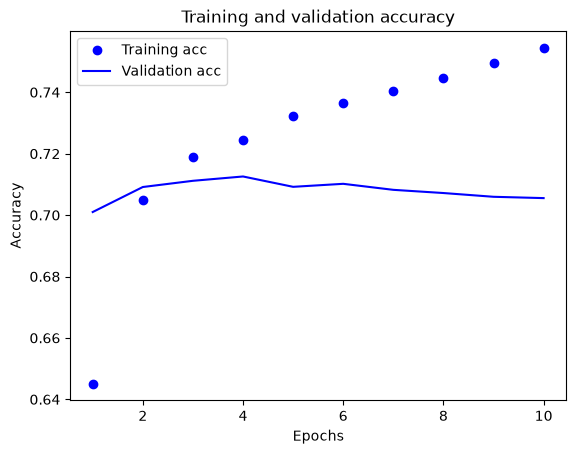

In [47]:
plot_acc_curves(history)

In [48]:
model.evaluate(x=X_test, y=y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7072 - loss: 0.7223


[0.7222751379013062, 0.7071737051010132]

In [49]:
emb = model.layers[1]
emb.weights

[<Variable path=embedding_3/embeddings, shape=(5000, 64), dtype=float32, value=[[ 0.00822203 -0.01623904  0.02718992 ... -0.01419135 -0.0232712
   -0.03445933]
  [-0.15070863  0.08538225 -0.06392862 ...  0.09800009  0.00384256
   -0.10642567]
  [-0.05103091 -0.00188859  0.05515558 ...  0.09202161 -0.16024469
   -0.12050272]
  ...
  [-0.06060316 -0.3301352  -0.0981112  ... -0.06743711  0.15331225
    0.31003344]
  [ 0.76799047  0.60795426  0.5597802  ... -0.54758185 -0.532452
   -0.77414984]
  [ 0.05963511  1.0923146   0.6552715  ...  0.2037173  -0.22317947
   -1.0034046 ]]>]